# Web Mining project

Alexandre Picart and Simon Simus

## Install Library 

In [28]:
!pip install gensim
!pip install sentence-transformers

In [29]:

import pandas as pd
import numpy as np
import os
from nltk.corpus import sentiwordnet as swn
import re
from nltk.tokenize import word_tokenize
import gensim.downloader as api
from collections import Counter
from sentence_transformers import SentenceTransformer
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, cohen_kappa_score, classification_report
from xgboost import XGBClassifier

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('sentiwordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\simus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\simus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\simus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package sentiwordnet to
[nltk_data]     C:\Users\simus\AppData\Roaming\nltk_data...
[nltk_data]   Package sentiwordnet is already up-to-date!


True

In [30]:

#Loading json files


path_events = 'database\\Nodes\\Event.json'
events = pd.read_json(
    path_events,
    lines=True
)

path_users = 'database\\Nodes\\User.json'
users = pd.read_json(
    path_users,
    lines=True
)

path_tweets = 'database\\Nodes\\Tweet.json'
tweets = pd.read_json(
    path_tweets,
    lines=True
)

path_postcategory = 'database\\Nodes\\PostCategory.json'
postcategory = pd.read_json(
    path_postcategory,
    lines=True
)



In [31]:
print(tweets.columns.tolist())

tweets['n'].iloc[10]
#we can see that there is only one column that contaains a json format (or dictionnary)
#we will need to extract the data from this column to be able to work with it

['n']


{'type': 'node',
 'id': '592',
 'labels': ['Tweet'],
 'properties': {'isTruncated': False,
  'possibly_sensitive': True,
  'created_at': '2012-06-10T00:00Z',
  'retweet_count': 0,
  'annotation_annotated': True,
  'is_quote_status': False,
  'annotation_postPriority': 'Low',
  'annotation_num_judgements': 1,
  'id_str': '211790625530593282',
  'topic': 'TRECIS-CTIT-H-001',
  'favorite_count': 0,
  'id': 211790625530593282,
  'text': 'New #HighParkFire Evacs: 474 evac notices S &amp; W of Bellvue includes Lory State Park, Redstone Canyon &amp; Buckhorn Rd to Stove Prairie School'}}

In [32]:
df_events = pd.json_normalize(events['n'])
df_postcategory = pd.json_normalize(postcategory['n'])
df_user = pd.json_normalize(users['n'])
df_tweets = pd.json_normalize(tweets['n'])

print(df_tweets.columns.tolist())

['type', 'id', 'labels', 'properties.isTruncated', 'properties.possibly_sensitive', 'properties.created_at', 'properties.retweet_count', 'properties.annotation_annotated', 'properties.is_quote_status', 'properties.annotation_num_judgements', 'properties.annotation_postPriority', 'properties.id_str', 'properties.topic', 'properties.favorite_count', 'properties.id', 'properties.text']


## Part 4.1 Core Search System on the Tweet Corpus

### Step 1  Load data and map tweets to event types

In [33]:
# Build a clean working dataframe with the columns we need
df = df_tweets.copy()

# Map each tweet to its event type via the trecisid key
df = df.merge(
    df_events[['properties.trecisid', 'properties.eventType']],
    how='left',
    left_on='properties.topic',
    right_on='properties.trecisid'
)
df.rename(columns={
    'properties.text': 'text',
    'properties.annotation_postPriority': 'priority',
    'properties.id': 'tweet_id',
    'properties.created_at': 'created_at',
    'properties.topic': 'topic',
    'properties.eventType': 'eventType'
}, inplace=True)

df['created_at'] = pd.to_datetime(df['created_at'], utc=True, errors='coerce')

event_types = sorted(df['eventType'].dropna().unique())
print("Event types:", event_types)
print("Total tweets:", len(df))
print(df[['tweet_id', 'topic', 'eventType', 'priority', 'created_at']].head())


Event types: ['bombing', 'earthquake', 'flood', 'shooting', 'typhoon', 'wildfire']
Total tweets: 55986
             tweet_id              topic eventType priority  \
0  211281973870727170  TRECIS-CTIT-H-001  wildfire      Low   
1  211557401231495171  TRECIS-CTIT-H-001  wildfire   Medium   
2  211565974422425600  TRECIS-CTIT-H-001  wildfire     High   
3  211607187653533697  TRECIS-CTIT-H-001  wildfire   Medium   
4  211654415503990784  TRECIS-CTIT-H-001  wildfire   Medium   

                 created_at  
0 2012-06-09 00:00:00+00:00  
1 2012-06-09 00:00:00+00:00  
2 2012-06-09 00:00:00+00:00  
3 2012-06-09 00:00:00+00:00  
4 2012-06-10 00:00:00+00:00  


### Step 2  Tokenization and text cleaning

In [34]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('stopwords')

def clean_and_tokenize(text):
    """Lower-case, strip URLs/mentions/digits/punctuation, then tokenize."""
    if not isinstance(text, str) or not text:
        return []
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)          # keep hashtag text, remove #
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    return word_tokenize(text)

df['tokens'] = df['text'].apply(clean_and_tokenize)
df['cleaned_text'] = df['tokens'].apply(lambda x: ' '.join(x))

# Stopwords
english_sw = set(stopwords.words('english'))
extra_sw = {'rt', 'amp', 'http', 'https', 'co', 'would', 'could',
            'also', 'us', 'via', 'im', 'get', 'got', 'still',
            'one', 'two', 'new', 'news', 'please'}
stop_words = english_sw | extra_sw

for i in range(10):
    print(f"  Raw   : {df['text'].iloc[i]}")
    print(f"  Tokens: {df['tokens'].iloc[i]}")
    print()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\simus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


  Raw   : #colorado. Told you its #amazing http://t.co/6z0Qq7qe
  Tokens: ['colorado', 'told', 'you', 'its', 'amazing']

  Raw   : RT @northfortynews: Tanker helicopter heads up to Paradise Park to drop water on #HighParkFire. http://t.co/7atRS5cy
  Tokens: ['rt', 'tanker', 'helicopter', 'heads', 'up', 'to', 'paradise', 'park', 'to', 'drop', 'water', 'on', 'highparkfire']

  Raw   : #Evacuation center Cache La Poudre Middle School 3515 West County Road 54G in Laporte. #Colorado #Wildfire
  Tokens: ['evacuation', 'center', 'cache', 'la', 'poudre', 'middle', 'school', 'west', 'county', 'road', 'g', 'in', 'laporte', 'colorado', 'wildfire']

  Raw   : 20F degrees cooler tomorrow in North Central &amp; Northeastern #Colorado. Highs in the mid and upper 70'S. #HighParkFire #COwx #Heat #Coolbreak
  Tokens: ['f', 'degrees', 'cooler', 'tomorrow', 'in', 'north', 'central', 'amp', 'northeastern', 'colorado', 'highs', 'in', 'the', 'mid', 'and', 'upper', 's', 'highparkfire', 'cowx', 'heat', 'coolbr

### Step 3 — Word embeddings with GloVe-Twitter-25

We use gensim.downloader`to load **GloVe-Twitter-25** (25-dimensional vectors trained on
Twitter data). This model is better suited than Word2Vec-Google-News for tweet content.


In [35]:
# Load glove twitter 25-d model

word_vectors = api.load("glove-twitter-25")
print("Model loaded. Vocabulary size:", len(word_vectors))

def is_valid_token(token):
    """Keep only alphabetic tokens not in stopwords that exist in the model."""
    return (
        isinstance(token, str)
        and len(token) > 2
        and token.isalpha()
        and token not in stop_words
        and token in word_vectors
    )

def get_word_embeddings(tokens):
    """Return list of GloVe vectors for valid tokens."""
    return [word_vectors[t] for t in tokens if is_valid_token(t)]

df['word_embeddings'] = df['tokens'].apply(get_word_embeddings)

print("Sample word embedding shape:", df['word_embeddings'].iloc[0][0].shape)

Model loaded. Vocabulary size: 1193514
Sample word embedding shape: (25,)


### Step 4 Semantic map: word-embedding clusters per event type (ex flooding, earthquake)

For each event type we:
1. Collect the top50 most frequent valid words.
2. Retrieve their GloVe vectors and apply kmean with k=5
3. Reduce to 2D with PCA and plot.


{'BOMBING'}


c:\Users\simus\anaconda3\envs\ML_DL\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


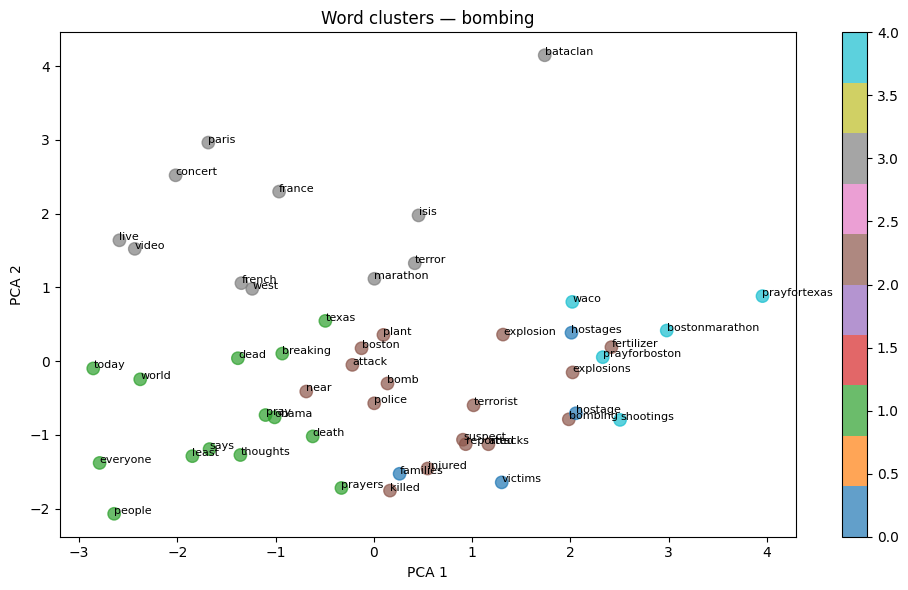

  Cluster 0: ['victims', 'hostages', 'families', 'hostage']
  Cluster 1: ['texas', 'people', 'dead', 'world', 'prayers', 'breaking', 'least', 'says', 'thoughts', 'everyone', 'today', 'obama', 'pray', 'death']
  Cluster 2: ['attacks', 'boston', 'explosion', 'plant', 'police', 'fertilizer', 'attack', 'bombing', 'explosions', 'killed', 'bomb', 'near', 'injured', 'suspect', 'terrorist', 'reported']
  Cluster 3: ['paris', 'west', 'marathon', 'france', 'french', 'video', 'bataclan', 'live', 'isis', 'concert', 'terror']
  Cluster 4: ['prayforboston', 'waco', 'prayfortexas', 'bostonmarathon', 'shootings']
{'EARTHQUAKE'}


c:\Users\simus\anaconda3\envs\ML_DL\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


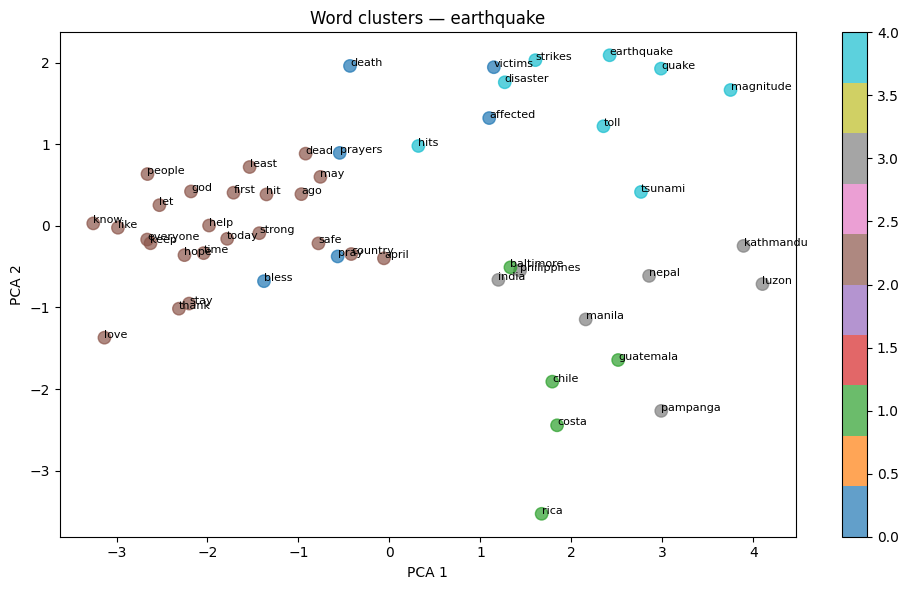

  Cluster 0: ['prayers', 'pray', 'affected', 'death', 'victims', 'bless']
  Cluster 1: ['chile', 'costa', 'rica', 'guatemala', 'baltimore']
  Cluster 2: ['people', 'help', 'safe', 'god', 'hit', 'everyone', 'strong', 'stay', 'today', 'hope', 'may', 'time', 'least', 'let', 'dead', 'like', 'keep', 'know', 'ago', 'love', 'april', 'first', 'thank', 'country']
  Cluster 3: ['nepal', 'philippines', 'manila', 'luzon', 'pampanga', 'kathmandu', 'india']
  Cluster 4: ['earthquake', 'magnitude', 'quake', 'hits', 'toll', 'tsunami', 'strikes', 'disaster']
{'FLOOD'}


c:\Users\simus\anaconda3\envs\ML_DL\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


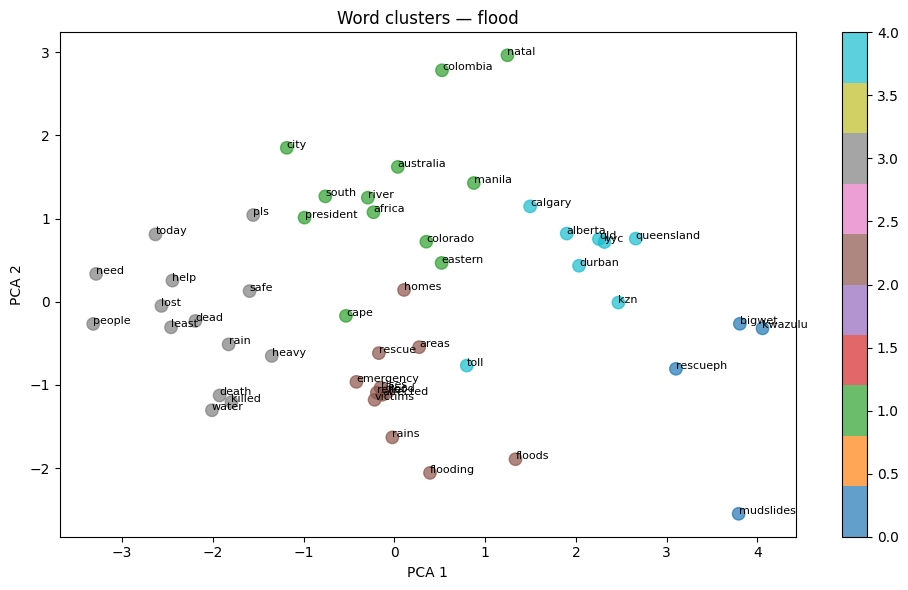

  Cluster 0: ['bigwet', 'rescueph', 'kwazulu', 'mudslides']
  Cluster 1: ['south', 'africa', 'colorado', 'river', 'colombia', 'manila', 'natal', 'cape', 'city', 'eastern', 'australia', 'president']
  Cluster 2: ['floods', 'flood', 'flooding', 'rains', 'affected', 'emergency', 'victims', 'relief', 'rises', 'homes', 'rescue', 'areas']
  Cluster 3: ['people', 'help', 'heavy', 'water', 'dead', 'death', 'rain', 'least', 'killed', 'need', 'today', 'safe', 'pls', 'lost']
  Cluster 4: ['durban', 'kzn', 'toll', 'calgary', 'yyc', 'qld', 'alberta', 'queensland']
{'SHOOTING'}


c:\Users\simus\anaconda3\envs\ML_DL\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


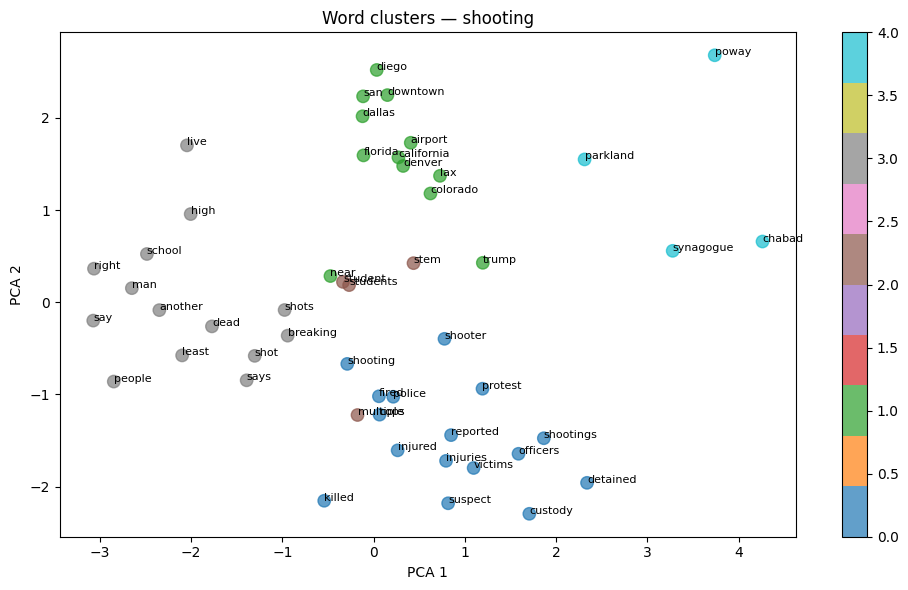

  Cluster 0: ['shooting', 'injured', 'police', 'shootings', 'suspect', 'protest', 'cops', 'officers', 'custody', 'shooter', 'killed', 'reported', 'fired', 'detained', 'victims', 'injuries']
  Cluster 1: ['dallas', 'san', 'diego', 'lax', 'colorado', 'florida', 'california', 'near', 'denver', 'downtown', 'airport', 'trump']
  Cluster 2: ['multiple', 'students', 'student', 'stem']
  Cluster 3: ['school', 'people', 'dead', 'shot', 'another', 'man', 'least', 'say', 'breaking', 'live', 'high', 'shots', 'says', 'right']
  Cluster 4: ['synagogue', 'poway', 'parkland', 'chabad']
{'TYPHOON'}


c:\Users\simus\anaconda3\envs\ML_DL\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


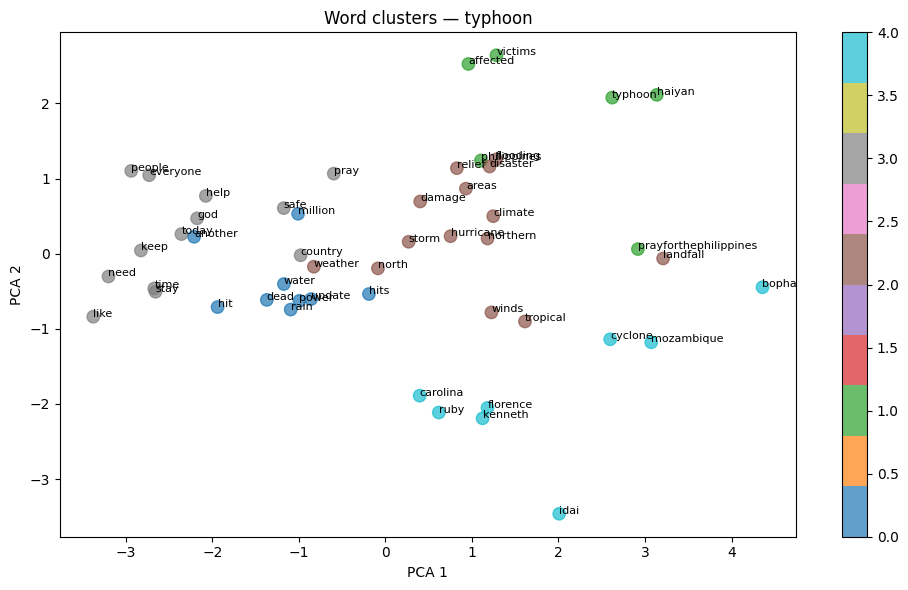

  Cluster 0: ['hit', 'rain', 'dead', 'power', 'another', 'update', 'water', 'million', 'hits']
  Cluster 1: ['typhoon', 'philippines', 'haiyan', 'affected', 'prayforthephilippines', 'victims']
  Cluster 2: ['hurricane', 'storm', 'flooding', 'landfall', 'tropical', 'winds', 'north', 'weather', 'northern', 'relief', 'damage', 'climate', 'disaster', 'areas']
  Cluster 3: ['people', 'safe', 'help', 'everyone', 'pray', 'stay', 'keep', 'today', 'need', 'god', 'like', 'country', 'time']
  Cluster 4: ['mozambique', 'cyclone', 'kenneth', 'florence', 'ruby', 'idai', 'carolina', 'bopha']
{'WILDFIRE'}


c:\Users\simus\anaconda3\envs\ML_DL\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


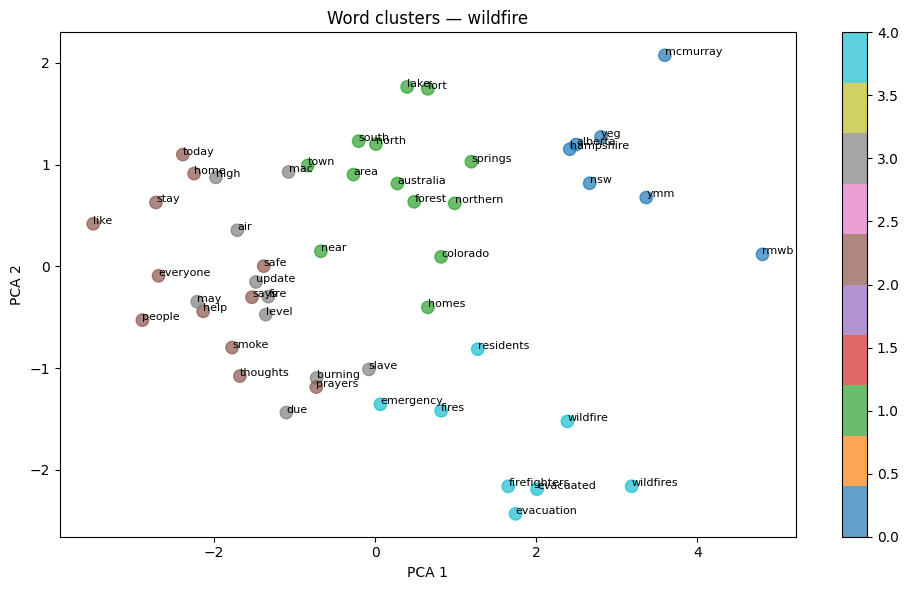

  Cluster 0: ['ymm', 'alberta', 'mcmurray', 'yeg', 'nsw', 'hampshire', 'rmwb']
  Cluster 1: ['colorado', 'fort', 'northern', 'lake', 'town', 'near', 'area', 'homes', 'north', 'south', 'springs', 'forest', 'australia']
  Cluster 2: ['safe', 'smoke', 'people', 'everyone', 'stay', 'today', 'help', 'thoughts', 'like', 'says', 'home', 'prayers']
  Cluster 3: ['fire', 'high', 'level', 'update', 'slave', 'air', 'due', 'burning', 'may', 'mac']
  Cluster 4: ['wildfire', 'fires', 'wildfires', 'evacuation', 'firefighters', 'residents', 'emergency', 'evacuated']


In [36]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def word_clustering_by_event(event_type, top_n=50, k=5):
    subset = df[df['eventType'] == event_type]
    valid_tokens = [t for tokens in subset['tokens'] for t in tokens if is_valid_token(t)]
    word_counts = Counter(valid_tokens)
    top_words = [w for w, _ in word_counts.most_common(top_n)]
    
    if len(top_words) < k:
        print(f"  Not enough words for {event_type}")
        return None

    embeddings = np.array([word_vectors[w] for w in top_words])
    kmeans = KMeans(n_clusters=min(k, len(top_words)), random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)
    
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(embeddings)
    
    return pd.DataFrame({
        'word': top_words,
        'cluster': cluster_labels,
        'x': coords[:, 0],
        'y': coords[:, 1]
    })

for event_type in event_types:
    print({event_type.upper()})
    df_cl = word_clustering_by_event(event_type)
    if df_cl is None:
        continue

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(df_cl['x'], df_cl['y'], c=df_cl['cluster'],
                          cmap='tab10', s=80, alpha=0.7)
    plt.colorbar(scatter)
    for _, row in df_cl.iterrows():
        plt.text(row['x'], row['y'], row['word'], fontsize=8)
    plt.title(f"Word clusters — {event_type}")
    plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
    plt.tight_layout()
    plt.show()

    for cid in sorted(df_cl['cluster'].unique()):
        words = df_cl[df_cl['cluster'] == cid]['word'].tolist()
        print(f"  Cluster {cid}: {words}")

### Step 5 Semantic map: tweet-embedding clusters per event type

For tweets embeding we use sentence Transformer (all-miniLM-L6-v2)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7411.45it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 875/875 [02:47<00:00,  5.23it/s]


BOMBING 


c:\Users\simus\anaconda3\envs\ML_DL\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


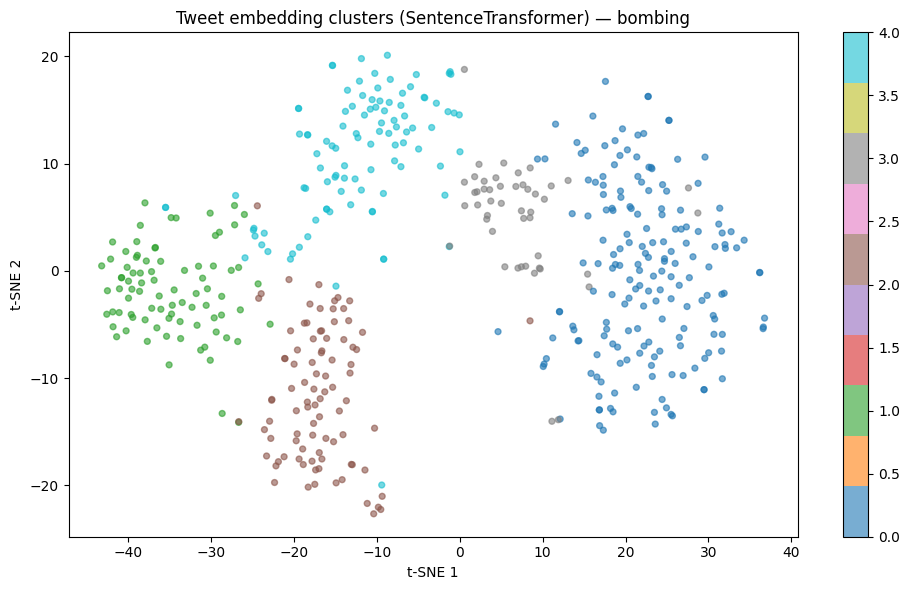

  reprensentative twweets for 'bombing':
    Cluster 0: Paris attacks: Horror as terror strikes France again, killing 153 people !

https://t.co/OlDOcRaM87

Terrorists... https://t.co/brmy3tIqjp …
    Cluster 1: 60 Reported Dead in Fertilizer Plant Explosion in West, Texas. 
4 Block Area Leveled. 
Entire Town Being Evacuated
http://t.co/mQtJKMbmOG …
    Cluster 2: Condolences to the victims of the Boston marathon explosions …
    Cluster 3: @emejotazm @ivymarina1 @tonijua37 @KetinaNovella @madcrazyzombie @jussizzz @BarrettKays @uhenha #PrayForParis ?????? YES! Pray For Paris! …
    Cluster 4: RT @HuseM: Oh no. #prayforparis …
EARTHQUAKE 


c:\Users\simus\anaconda3\envs\ML_DL\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


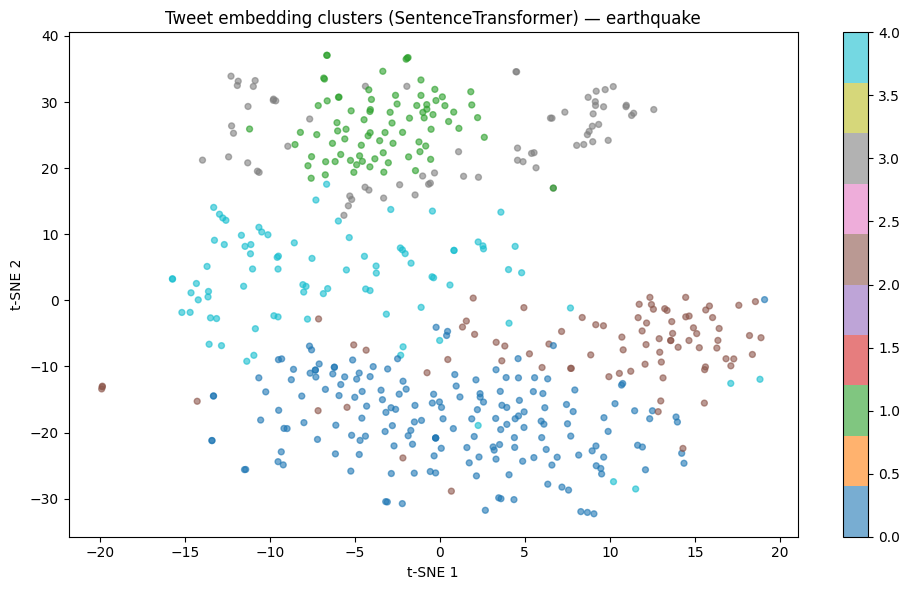

  reprensentative twweets for 'earthquake':
    Cluster 0: @katyperry @UNICEF help Nepal there people. God bless Nepal. #NepalEarthquake …
    Cluster 1: Keep Safe Philippines!! I heard about the earthquake. ?? …
    Cluster 2: More than 1,900 dead in devastating Nepal earthquake http://t.co/8l2n6GANpo http://t.co/U5O80Z2KIu …
    Cluster 3: Earthquake here in Cebu,Philippines. I expected it to happen but I'm still shock goshh …
    Cluster 4: Let's retweet this and #PrayForThePhilippines #PrayForVisayas #PrayforBohol #PrayForCebu #PRAY #BangonPilipinas …
FLOOD 


c:\Users\simus\anaconda3\envs\ML_DL\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


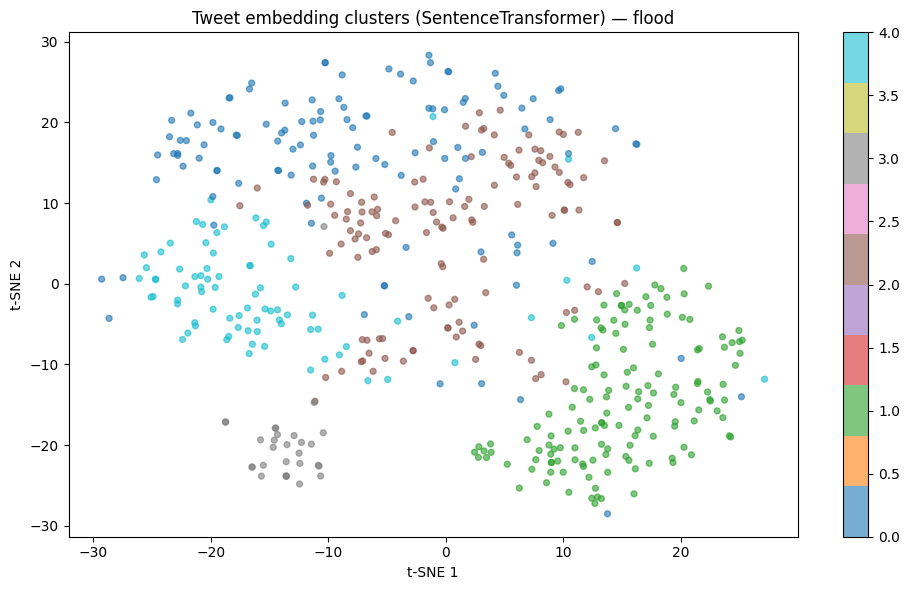

  reprensentative twweets for 'flood':
    Cluster 0: RT @JohnCBS4: Not for those with a weak stomach: Larimer County Sheriff's flyover to survey the #COflood damage. http://t.co/zZWrNvDWxu …
    Cluster 1: BBC News - South Africa floods: Death toll after Durban rains rises to 60 https://t.co/rcoIpiQf9a …
    Cluster 2: Watching the news coverage of the QLD floods #besafe everyone in the affected areas …
    Cluster 3: RT @Gabriele_Corno: Rainbow River in #Colombia ?? https://t.co/RHLC06C4Nf …
    Cluster 4: RT @gmanews: Update as of 2:00 AM, where to bring your donations or to volunteer http://t.co/05Anrld6 #ReliefPH …
SHOOTING 


c:\Users\simus\anaconda3\envs\ML_DL\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


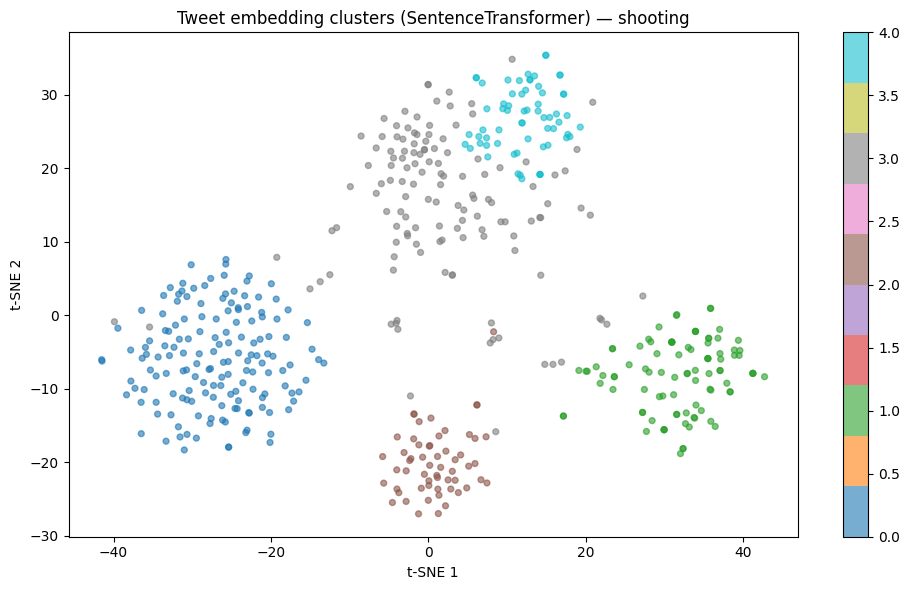

  reprensentative twweets for 'shooting':
    Cluster 0: Oh shit! Shooting going on in Dallas at protest. Apparently some cops shot. https://t.co/0pJHqSHWJv …
    Cluster 1: Shooting reported at San Diego-area synagogue https://t.co/COZnd0iD6l …
    Cluster 2: RT @heatherhoylee: The shooting at LAX is going to make airport security even more of a pain in the ass …
    Cluster 3: another school shooting in America ? …
    Cluster 4: school shooting in Colorado, 2 injured …
TYPHOON 


c:\Users\simus\anaconda3\envs\ML_DL\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


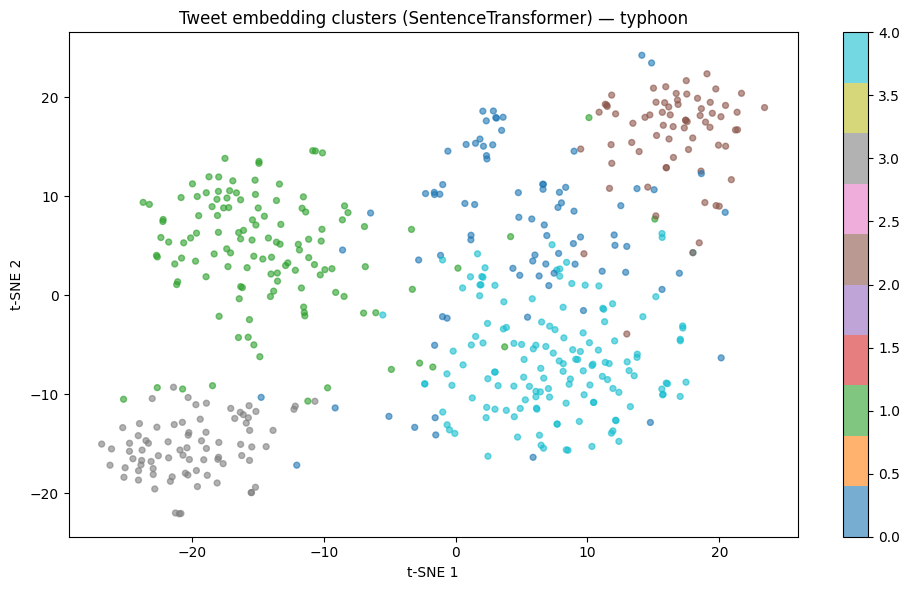

  reprensentative twweets for 'typhoon':
    Cluster 0: RT @iamsuperbianca: kamusta kayo diyan sa visayas at mindanao? stay safe. we are praying for you. use hashtags #reliefPH #rescuePH if ne ... …
    Cluster 1: #HappeningNow @NC_Governor on Hurricane #Florence: "Don't relax, don't get complacent, stay on guard, this is a powerful storm that can kill …
    Cluster 2: Stay safe ? #RubyPH …
    Cluster 3: Another huge cyclone hits Mozambique - thinking of my colleagues there. Cyclone Kenneth: Mozambique hit by its strongest storm ever https:// …
    Cluster 4: Typhoon in the Philippines http://t.co/wn3RAt0n3j …
WILDFIRE 


c:\Users\simus\anaconda3\envs\ML_DL\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


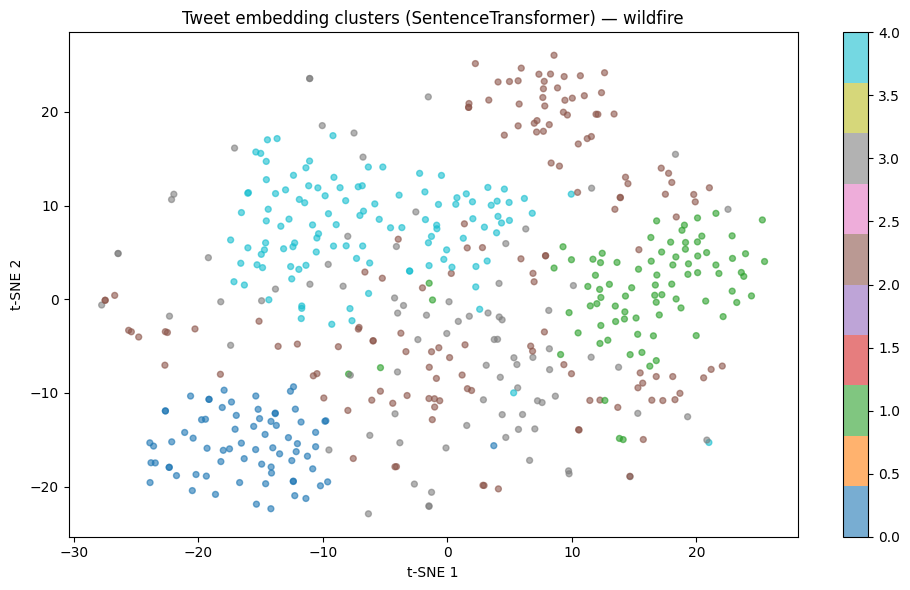

  reprensentative twweets for 'wildfire':
    Cluster 0: RT @NSWRFS: Emergency Warning - Linksview Road, Springwood (Blue Mtns) http://t.co/jxgwWvxprL Firefighters are on scene. #NSWRFS #nswfires …
    Cluster 1: The threat of another record-breaking wildfire season. Fires have already forced evacuations in High Level and the Dene Tha? First Nation in …
    Cluster 2: Faced with epic conditions and safety concerns related to the wildfires threatening Colorado Springs and nearby... http://t.co/MixIKiuU …
    Cluster 3: Our thoughts are with those affected and currently evacuated by the #HighLevelFire.

For more information and, evacuation locations check ou …
    Cluster 4: sending thoughts and prayers to my old hometown. Devastating to see... #ymmfire https://t.co/rFobxtGHfr …


In [37]:
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.manifold import TSNE

# Encode all tweets once with SentenceTransformer 
st_model = SentenceTransformer('all-MiniLM-L6-v2')
df['st_embedding'] = list(st_model.encode(
    df['cleaned_text'].fillna('').tolist(),
    show_progress_bar=True,
    batch_size=64
))

def cluster_tweet_embeddings(event_type, k=5, sample_size=500, random_state=42):
    subset = df[df['eventType'] == event_type].copy().reset_index(drop=True)
    subset = subset[subset['st_embedding'].apply(lambda v: isinstance(v, np.ndarray))].reset_index(drop=True)


    # choose nb cluster with min(sample_size, len(subset)) points
    plot_subset = subset.sample(min(sample_size, len(subset)), random_state=random_state).reset_index(drop=True)
    X_plot = np.vstack(plot_subset['st_embedding'].values)

    kmeans = KMeans(n_clusters=min(k, len(plot_subset)), random_state=random_state, n_init=10)
    plot_labels = kmeans.fit_predict(X_plot)

    tsne = TSNE(n_components=2, perplexity=min(30, len(plot_subset) - 1),
                init='pca', max_iter=1000, random_state=random_state)
    X2d = tsne.fit_transform(X_plot)

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(X2d[:, 0], X2d[:, 1], c=plot_labels,
                          cmap='tab10', s=18, alpha=0.6)
    plt.colorbar(scatter)
    plt.title(f"Tweet embedding clusters (SentenceTransformer) — {event_type}")
    plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()

    closest_idx, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X_plot)
    print(f"  reprensentative twweets for '{event_type}':")
    for cid, idx in enumerate(closest_idx):
        print(f"    Cluster {cid}: {str(plot_subset.loc[idx, 'text'])[:140]} …")

    return plot_subset

for event_type in event_types:
    print(f"{event_type.upper()} ")
    cluster_tweet_embeddings(event_type)


## PART 1.2 : Question-Answering system: two-stage retriever–re-ranker (Q2)
Architecture
1. **Stage 1 – Bi-encoder retrieval**: encode all tweets with all-MiniLM-L6-v2 and compute cosine similarity to retrieve the top-1000 candidates.
2. **Stage 2 – Cross-encoder re-ranking**: re-score each (query, tweet) pair with cross-encoder/ms-marco-MiniLM-L-6-v2 and keep the top-10.

In [38]:
from sentence_transformers import SentenceTransformer, CrossEncoder
from sklearn.metrics.pairwise import cosine_similarity


corpus_text = list(df['text'].dropna().values)
corpus_ids  = list(df.loc[df['text'].notna(), 'tweet_id'].values)


bi_encoder = SentenceTransformer('all-MiniLM-L6-v2')

#take very long time to run !
# corpus_embeddings = bi_encoder.encode(corpus_text, show_progress_bar=True, batch_size=64)



Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7007.74it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [39]:
#since it takes a long time to run, we will save the embeddings to a file and load them later
# np.save('corpus_embeddings.npy', corpus_embeddings)
corpus_embeddings = np.load('corpus_embeddings.npy')

In [40]:
def get_top_k_docs(queries_vec, corpus_vec, q_ids, c_ids, k=1000):
    sim = cosine_similarity(queries_vec, corpus_vec)
    rows = []
    for i, qid in enumerate(q_ids):
        for j, did in enumerate(c_ids):
            rows.append((qid, did, float(sim[i, j])))
    df_sim = pd.DataFrame(rows, columns=['id_q', 'id_t', 'score'])
    return (df_sim
            .sort_values(['id_q', 'score'], ascending=[True, False])
            .groupby('id_q').head(k))


RERANKER_MODEL = 'cross-encoder/ms-marco-MiniLM-L-6-v2'

def rerank_candidates(df_retrieve, query_texts, doc_texts, reranker_name, top_k=10):
    reranker = CrossEncoder(reranker_name)
    pairs = [[query_texts[r['id_q']], doc_texts[r['id_t']]]
             for _, r in df_retrieve.iterrows()]
    scores = reranker.predict(pairs)
    df_retrieve = df_retrieve.copy()
    df_retrieve['score_rerank'] = scores
    return (df_retrieve
            .sort_values(['id_q', 'score_rerank'], ascending=[True, False])
            .groupby('id_q').head(top_k))

In [41]:
#test with 4 queries:
#theses 4 questions come form  the id_t, for the tweet id associated to the question
test_query_df = pd.DataFrame({
    'id_q': ['q1', 'q2', 'q3', 'q4'],
    'text_q': [
        'Where is the evacuation center for the High Park Fire in Colorado?',
        'Did FEMA provide funds for the High Park Fire?',
        'How many acres has the High Park Fire burned and how many structures were damaged?',
        'Where can High Park Fire evacuees board their animals?'
    ],
    'id_t': [
        211565974422425600,
        211654415503990784,
        212202460046049280,
        211910322582335488
    ]
})


print(test_query_df[['id_q', 'text_q']].to_string(index=False))

id_q                                                                             text_q
  q1                 Where is the evacuation center for the High Park Fire in Colorado?
  q2                                     Did FEMA provide funds for the High Park Fire?
  q3 How many acres has the High Park Fire burned and how many structures were damaged?
  q4                             Where can High Park Fire evacuees board their animals?


In [42]:

query_texts_list = list(test_query_df['text_q'].values)
query_ids_list   = list(test_query_df['id_q'].values)

#encode query : 
queries_embeddings = bi_encoder.encode(query_texts_list, show_progress_bar=False)

df_stage1 = get_top_k_docs(queries_embeddings, corpus_embeddings,
                            query_ids_list, corpus_ids, k=1000)

query_text_dict = dict(zip(query_ids_list, query_texts_list))
doc_text_dict   = dict(zip(corpus_ids, corpus_text))


result_df = rerank_candidates(df_stage1, query_text_dict, doc_text_dict, RERANKER_MODEL)


result_df.head(10)

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 7000.28it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,id_q,id_t,score,score_rerank
153,q1,214426300994162688,0.659973,6.941738
51262,q1,212616976982482945,0.796684,6.452186
85,q1,212617322836398080,0.749868,6.051672
86,q1,212617469645438976,0.749868,6.051672
51263,q1,212676975830106113,0.705900,5.099428
91,q1,212678790353137664,0.700266,4.928787
138,q1,213966051640221697,0.670106,4.776628
139,q1,213967951626383360,0.670106,4.776628
2,q1,211565974422425600,0.617619,4.346189
134,q1,213702829674741761,0.578169,3.994512


In [43]:
#see results for each query with the original text of the retrieved tweet

result_display = result_df.copy()
result_display['question'] = result_display['id_q'].map(query_text_dict)
result_display['tweet'] = result_display['id_t'].map(doc_text_dict)

result_display[['id_q', 'question', 'tweet', 'score_rerank']].reset_index(drop=True)

,id_q,question,tweet,score_rerank
0,q1,Where is the evacuation center for the High Pa...,RT @coloradoan: #HighParkFire UPDATE: Re-Evacu...,6.941738
1,q1,Where is the evacuation center for the High Pa...,Evacuation order issued in Colorado's High Par...,6.452186
2,q1,Where is the evacuation center for the High Pa...,RT @BreakingNews: Evacuation order issued in C...,6.051672
3,q1,Where is the evacuation center for the High Pa...,RT @BreakingNews: Evacuation order issued in C...,6.051672
4,q1,Where is the evacuation center for the High Pa...,Colorado wildfire: some residents defy evacuat...,5.099428
5,q1,Where is the evacuation center for the High Pa...,RT @kmitchellDP: Colorado wildfire: some resid...,4.928787
6,q1,Where is the evacuation center for the High Pa...,Colorado wildfire: High Park Fire near Fort Co...,4.776628
7,q1,Where is the evacuation center for the High Pa...,Colorado wildfire: High Park Fire near Fort Co...,4.776628
8,q1,Where is the evacuation center for the High Pa...,#Evacuation center Cache La Poudre Middle Scho...,4.346189
9,q1,Where is the evacuation center for the High Pa...,RT @COEmergency: #HighParkFire Disaster Recove...,3.994512


### Evaluation :

In [44]:
def compute_precision(results_df, q_id, gold):
    pred   = set(results_df[results_df['id_q'] == q_id]['id_t'].values)
    golden = set(gold[gold['id_q'] == q_id]['id_t'].values)
    return len(pred & golden) / len(pred) if pred else 0.0

def compute_recall(results_df, q_id, gold):
    pred   = set(results_df[results_df['id_q'] == q_id]['id_t'].values)
    golden = set(gold[gold['id_q'] == q_id]['id_t'].values)
    return len(pred & golden) / len(golden) if golden else 0.0

def compute_mrr(results_df, q_id, gold):
    "MRR means for mean reciprocal rank"
    ranked = results_df[results_df['id_q'] == q_id]['id_t'].values
    golden = set(gold[gold['id_q'] == q_id]['id_t'].values)
    for rank, doc_id in enumerate(ranked, start=1):
        if doc_id in golden:
            return 1.0 / rank
    return 0.0

precisions, recalls, mrrs = [], [], []
for q in test_query_df['id_q']:
    p   = compute_precision(result_df, q, test_query_df)
    r   = compute_recall(result_df, q, test_query_df)
    mrr = compute_mrr(result_df, q, test_query_df)
    precisions.append(p); recalls.append(r); mrrs.append(mrr)
    k_gold = len(test_query_df[test_query_df['id_q'] == q])
    print(f"Query {q}: P@{k_gold}={p:.4f}  R@{k_gold}={r:.4f}  MRR={mrr:.4f}")


Query q1: P@1=0.1000  R@1=1.0000  MRR=0.1111
Query q2: P@1=0.1000  R@1=1.0000  MRR=1.0000
Query q3: P@1=0.1000  R@1=1.0000  MRR=0.3333
Query q4: P@1=0.1000  R@1=1.0000  MRR=1.0000


## Part 2: Predict the priority of a tweet post to feed it at the right time to the right emergency officier

1. Split data into training and testing subsets. 

In [45]:
#train test split of the required data
from sklearn.model_selection import train_test_split

valid_labels = ['High', 'Medium', 'Low']
df_priority = df[df['priority'].isin(valid_labels)].copy()
df_priority = df_priority.dropna(subset=['text', 'priority'])

print("Distribution of classes :")
print(df_priority['priority'].value_counts())

X = df_priority.drop(columns=['priority'])
y = df_priority['priority']

#split data into train and test (70% train, 30% test) with stratification to maintain class distribution
#the stratify parameter allows to work with imbalanced data and to maintain the 
# same distribution of classes in both train and test sets
#we will use smote to balance the classes in the training set later (or parameter class_weight='balanced')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(y_train.value_counts(normalize=True) * 100)

Distribution of classes :
priority
Low       25407
Medium     6629
High       4155
Name: count, dtype: int64
priority
Low       70.200924
Medium    18.316030
High      11.483046
Name: proportion, dtype: float64


2. Definition and implementation of features

In [46]:
from sklearn.preprocessing import StandardScaler

def extract_features(df_X, embeddings):
    
    #retrieve the SentenceTransformer embeddings already computed in Part 1
    content_emb = embeddings[df_X.index]

    #keep retweet and favorite counts as proxies for tweet popularity and reshape in a column vector
    retweets  = df_X['properties.retweet_count'].fillna(0).values.reshape(-1, 1)
    favorites = df_X['properties.favorite_count'].fillna(0).values.reshape(-1, 1)

    #boolean: 1 if the tweet contains a hashtag 0 otherwise
    has_hashtag = df_X['text'].str.contains('#').astype(int).values.reshape(-1, 1)

    #tweet length (nb of words after tokenization)
    #idea : longer tweets may contain more information ==> more likely to be high priority
    tweet_length = df_X['text'].fillna('').apply(lambda x: len(x.split())).values.reshape(-1, 1)
    
    # combine all features into a single matrix
    return np.hstack((content_emb, retweets, favorites, has_hashtag, tweet_length))


# Retrieve the SentenceTransformer embeddings computed in Part 1
all_embeddings = np.vstack(df['st_embedding'].values)

X_train_features = extract_features(X_train, all_embeddings)
X_test_features  = extract_features(X_test,  all_embeddings)

#use scaler to have all features between -1 and 1
scaler = StandardScaler()
X_train_features = scaler.fit_transform(X_train_features)
X_test_features  = scaler.transform(X_test_features)

3. Learning predictive model and use SMOTE in order to balanced data

In [47]:


# Since dataset umbalanced we use SMOTE  togenerates synthetic samples for minority classes 
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_features, y_train)

print("class distribution after smote")
print(pd.Series(y_train_bal).value_counts())

#xgboost requires numeric label
le = LabelEncoder()
y_train_bal_enc = le.fit_transform(y_train_bal)
y_test_enc = le.transform(y_test)


models = {
    'Logistic Regression': LogisticRegression(max_iter=1000,random_state=1),
    'Random Forest':       RandomForestClassifier(n_estimators=100,random_state=1),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=1, eval_metric='mlogloss')
}

#trainting and evaluating each model with F1 Macro and Cohen's Kappa metric
results = []
for name, model in models.items():
    print(f"\nTraining {name} ...")

    #special case for numeric labels with xgboost
    if name == 'XGBoost':
        model.fit(X_train_bal, y_train_bal_enc)
        y_pred = le.inverse_transform(model.predict(X_test_features))
    else:
        model.fit(X_train_bal, y_train_bal)
        y_pred = model.predict(X_test_features)

    f1    = f1_score(y_test, y_pred, average='macro')
    kappa = cohen_kappa_score(y_test, y_pred)
    results.append({'Model': name, 'F1': f1, "Cohen's Kappa": kappa})

    print(classification_report(y_test, y_pred))

pd.DataFrame(results)

class distribution after smote
priority
Low       17784
High      17784
Medium    17784
Name: count, dtype: int64

Training Logistic Regression ...
              precision    recall  f1-score   support

        High       0.29      0.56      0.38      1246
         Low       0.88      0.66      0.75      7623
      Medium       0.35      0.48      0.41      1989

    accuracy                           0.62     10858
   macro avg       0.51      0.57      0.51     10858
weighted avg       0.71      0.62      0.65     10858


Training Random Forest ...
              precision    recall  f1-score   support

        High       0.48      0.33      0.39      1246
         Low       0.80      0.90      0.85      7623
      Medium       0.48      0.37      0.42      1989

    accuracy                           0.73     10858
   macro avg       0.59      0.53      0.55     10858
weighted avg       0.71      0.73      0.72     10858


Training XGBoost ...
              precision    recall  f1-sc

,Model,F1,Cohen's Kappa
0,Logistic Regression,0.513213,0.311101
1,Random Forest,0.551266,0.361128
2,XGBoost,0.551307,0.357174


random forest and xgboost seem to have better resultat than logistic regression

In [48]:
#we can try without smote and with class_weight='balanced' to see if it improves the result


models_balanced = {
    'Logistic Regression (balanced)': LogisticRegression(max_iter=1000, random_state=1, class_weight='balanced'),
    'Random Forest (balanced)':       RandomForestClassifier(n_estimators=100, random_state=1, class_weight='balanced'),
    'XGBoost (balanced)':             XGBClassifier(n_estimators=100, random_state=1, eval_metric='mlogloss'),
}
y_train_enc = le.transform(y_train)

results_balanced = []
for name, model in models_balanced.items():
    print(f"\nTraining {name} ...")

    if name == 'XGBoost (balanced)':
        model.fit(X_train_features, y_train_enc)  # needs encoded labels
        y_pred = le.inverse_transform(model.predict(X_test_features))
    else:
        model.fit(X_train_features, y_train)
        y_pred = model.predict(X_test_features)

    f1    = f1_score(y_test, y_pred, average='macro')
    kappa = cohen_kappa_score(y_test, y_pred)
    results_balanced.append({'Model': name, 'F1 Macro': f1, "Cohen's Kappa": kappa})

    print(classification_report(y_test, y_pred))

#comparision betwwen smote and class_weight
print("smote results")
display(pd.DataFrame(results))
print("class_weight results")
display(pd.DataFrame(results_balanced))


Training Logistic Regression (balanced) ...


              precision    recall  f1-score   support

        High       0.29      0.57      0.38      1246
         Low       0.88      0.65      0.75      7623
      Medium       0.35      0.49      0.41      1989

    accuracy                           0.61     10858
   macro avg       0.51      0.57      0.51     10858
weighted avg       0.72      0.61      0.64     10858


Training Random Forest (balanced) ...


KeyboardInterrupt: 

results are better with smote

#### Try the cross validation with 5 folds to have more consistent results

warning !!! take a lot of time to run (around 10 min)

In [51]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, model in models.items():
    f1_scores = []
    kappa_scores = []
    
    X_cv = X_train_bal if name != 'XGBoost' else X_train_bal
    y_cv = y_train_bal if name != 'XGBoost' else y_train_bal_enc
    
    for train_idx, val_idx in skf.split(X_cv, y_cv):
        model.fit(X_cv[train_idx], y_cv[train_idx])
        y_pred = model.predict(X_cv[val_idx])
        
        if name == 'XGBoost':
            y_true = le.inverse_transform(y_cv[val_idx])
            y_pred = le.inverse_transform(y_pred)
        else:
            y_true = y_cv[val_idx]
        
        f1_scores.append(f1_score(y_true, y_pred, average='macro'))
        kappa_scores.append(cohen_kappa_score(y_true, y_pred))
    
    cv_results.append({
        'model': name,
        'mean_f1': np.mean(f1_scores),
        'std_f1': np.std(f1_scores),
        'mean_kappa': np.mean(kappa_scores),
        'std_kappa': np.std(kappa_scores)
    })

pd.DataFrame(cv_results)

,model,mean_f1,std_f1,mean_kappa,std_kappa
0,Logistic Regression,0.624797,0.006552,0.436881,0.009640
1,Random Forest,0.906853,0.002457,0.860577,0.003705
2,XGBoost,0.880293,0.002418,0.820654,0.003675


In [57]:
!pip install wandb
#if you don't have wandb, need to install and create a wandb account and add your 
# API key to be able to use it.

import wandb
KEY_API_WANDB ="your_api_key_here"
wandb.login(key=KEY_API_WANDB)

from nltk.corpus import sentiwordnet as swn
from nltk.corpus import wordnet as wn
nltk.download('averaged_perceptron_tagger_eng')

#we add a sentiment score to the feature
#intuition is that crisis tweets with strong negative sentiment tend to be higher priority
def get_sentiment_score(text):
    tokens = nltk.word_tokenize(str(text))
    pos_tags = nltk.pos_tag(tokens)
    score = 0
    for word, tag in pos_tags:
        wn_tag = None
        if tag.startswith('N'): wn_tag = wn.NOUN
        elif tag.startswith('V'): wn_tag = wn.VERB
        elif tag.startswith('J'): wn_tag = wn.ADJ
        elif tag.startswith('R'): wn_tag = wn.ADV
        if wn_tag:
            synsets = list(wn.synsets(word, pos=wn_tag))
            if synsets:
                swn_s = swn.senti_synset(synsets[0].name())
                score += (swn_s.pos_score() - swn_s.neg_score())
    return score

print("Computing sentiment scores (this may take a few minutes) ...")
X_train_sent = np.array([get_sentiment_score(t) for t in X_train['text']]).reshape(-1, 1)
X_test_sent  = np.array([get_sentiment_score(t) for t in X_test['text']]).reshape(-1, 1)

#add sentiment score to the feature matrix
X_train_imp = np.hstack((X_train_features, X_train_sent))
X_test_imp  = np.hstack((X_test_features,  X_test_sent))

# apply smote
X_train_bal_imp, y_train_bal_imp = SMOTE(random_state=42).fit_resample(X_train_imp, y_train)
y_train_bal_imp_enc = le.transform(y_train_bal_imp)


#weight and bias all to automate hyperparameter tuning for xgboost with bayesian optimization
#we choose parameter and value that we want to optimize and then the api call we will do the rest
#we can see on wandb website a dashboard of all run and see the best configuration
sweep_config = {
    'method': 'bayes',
    'metric': {
        'name': 'f1_macro',
        'goal': 'maximize'
    },
    'parameters': {
        'n_estimators': {
            'values': [50, 100, 200, 300]
        },
        'max_depth': {
            'values': [3, 5, 7, 10]
        },
        'learning_rate': {
            'distribution': 'uniform',
            'min': 0.01,
            'max': 0.3
        },
        'subsample': {
            'distribution': 'uniform',
            'min': 0.6,
            'max': 1.0
        },
        'colsample_bytree': {
            'distribution': 'uniform',
            'min': 0.6,
            'max': 1.0
        }
    }
}


def train():
    with wandb.init():
        config = wandb.config

        model = XGBClassifier(
            n_estimators     = config.n_estimators,
            max_depth        = config.max_depth,
            learning_rate    = config.learning_rate,
            subsample        = config.subsample,
            colsample_bytree = config.colsample_bytree,
            random_state     = 1,
            eval_metric      = 'mlogloss'
        )

        
        model.fit(X_train_bal_imp, y_train_bal_imp_enc)
        y_pred = le.inverse_transform(model.predict(X_test_imp))

        f1    = f1_score(y_test, y_pred, average='macro')
        kappa = cohen_kappa_score(y_test, y_pred)

        wandb.log({
            'f1_macro': f1,
            'kappa':    kappa
        })

#run sweep of wandb
sweep_id = wandb.sweep(sweep_config, project='webmining-project')
#only do 15 runs
wandb.agent(sweep_id, function=train, count=15)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\simus\_netrc


wandb: Currently logged in as: simon-s (simon-s-toulouse-school-of-economics) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\simus\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


Computing sentiment scores (this may take a few minutes) ...
Create sweep with ID: k843l7qh
Sweep URL: https://wandb.ai/simon-s-toulouse-school-of-economics/webmining-project/sweeps/k843l7qh


wandb: Agent Starting Run: nfaz8zm7 with config:
wandb: 	colsample_bytree: 0.6574519605460992
wandb: 	learning_rate: 0.14040364790931362
wandb: 	max_depth: 10
wandb: 	n_estimators: 50
wandb: 	subsample: 0.99509070555016
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\simus\_netrc.


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


...

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


f1_macro,▁
kappa,▁
f1_macro,0.55443
kappa,0.36516


wandb: Agent Starting Run: h2xlxklw with config:
wandb: 	colsample_bytree: 0.949160950324203
wandb: 	learning_rate: 0.27582704588279905
wandb: 	max_depth: 5
wandb: 	n_estimators: 300
wandb: 	subsample: 0.890898491507282
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\simus\_netrc.


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


f1_macro,▁
kappa,▁
f1_macro,0.5526
kappa,0.36144
